# Alzheimer MRI Classification using ResNet50
Train / Validation split from train folder, augmentation, evaluation and prediction.

In [1]:
# ===============================
# 1 Import Libraries
# ===============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight # For dynamic class weights

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.10.0


In [2]:
# ===============================
# 2 GPU Configuration
# ===============================

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPUs:", gpus)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
import shutil
import random
from pathlib import Path

def split_dataset(input_dir, output_dir, split_ratio=(0.7, 0.15, 0.15), seed=42):
    """
    Splits a dataset into train, val, and test sets.
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    
    # Ensure ratios sum up to 1
    train_ratio, val_ratio, test_ratio = split_ratio
    assert round(train_ratio + val_ratio + test_ratio, 5) == 1.0, "Ratios must sum to 1.0"
    
    # The folders you specified
    classes = ['down', 'normal']
    splits = ['train', 'val', 'test']
    
    # 1. Create the output directory structure
    for split in splits:
        for cls in classes:
            (output_path / split / cls).mkdir(parents=True, exist_ok=True)
            
    # Set seed for reproducibility
    random.seed(seed)
    
    # 2. Distribute files for each class
    for cls in classes:
        cls_dir = input_path / cls
        
        if not cls_dir.exists():
            print(f"Warning: Directory '{cls_dir}' does not exist. Skipping.")
            continue
            
        # Get all files in the class directory (ignoring hidden files/folders)
        files = [f for f in cls_dir.iterdir() if f.is_file() and not f.name.startswith('.')]
        random.shuffle(files)
        
        # Calculate split indices
        total_files = len(files)
        train_idx = int(total_files * train_ratio)
        val_idx = train_idx + int(total_files * val_ratio)
        
        # Slice the list of files
        train_files = files[:train_idx]
        val_files = files[train_idx:val_idx]
        test_files = files[val_idx:]
        
        # Helper function to copy files
        def copy_files(file_list, split_name):
            for f in file_list:
                dest = output_path / split_name / cls / f.name
                shutil.copy2(f, dest) # copy2 preserves metadata
                
        # Execute the copy
        copy_files(train_files, 'train')
        copy_files(val_files, 'val')
        copy_files(test_files, 'test')
        
        print(f"Class '{cls}': Copied {len(train_files)} train, {len(val_files)} val, {len(test_files)} test.")

# --- Run the Script ---
# This assumes your original folder is named "dataset" 
# and you want the split folders inside a new folder called "split_dataset"
split_dataset(
    input_dir='dataset', 
    output_dir='split_dataset', 
    split_ratio=(0.80, 0.10, 0.10) # 70% Train, 15% Validation, 15% Test
)

Class 'down': Copied 1200 train, 150 val, 150 test.
Class 'normal': Copied 1199 train, 149 val, 151 test.


In [4]:
# ===============================
# 3 Paths and Parameters
# ===============================

TRAIN_DIR = "split_dataset/train"
TEST_DIR = "split_dataset/test"
VAL_DIR   = "split_dataset/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

CLASSES = [
    'down', 'normal'

]


In [5]:
# ===============================
# 4 Load Train Dataset
# ===============================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    class_names=CLASSES, # Remember to keep this from our previous fix!
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 2399 files belonging to 2 classes.


In [6]:
# ===============================
# 5 Validation Dataset
# ===============================

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 299 files belonging to 2 classes.


In [7]:
# ===============================
# 6 Test Dataset
# ===============================

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # Crucial: Never shuffle the test set so your confusion matrix lines up
)

Found 301 files belonging to 2 classes.


In [8]:
# ===============================
# 7 Data Augmentation
# ===============================

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15),
])

def augment(images, labels):
    images = data_augmentation(images)
    return images, labels

train_dataset = train_dataset.map(augment)


In [9]:
# ===============================
# 8 ResNet Preprocessing
# ===============================

def preprocess(images, labels):
    images = preprocess_input(images)
    return images, labels

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)


In [10]:
# ===============================
# 9 Prefetch for performance
# ===============================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


In [15]:
# ===============================
# 10 Build ResNet Model
# ===============================
from tensorflow.keras import regularizers

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5), 
    layers.Dense(2, activation="softmax")
])

In [16]:
# ===============================
# 11 Compile Model
# ===============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 2048)              0         
                                                                 
 dense_2 (Dense)             (None, 2)                 4098      
                                                                 
Total params: 23,591,810
Trainable params: 4,098
Non-trainable params: 23,587,712
_________________________________________________________________


In [17]:
# ===============================
# 12 Training
# ===============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=12, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.3, 
    patience=3, 
    min_lr=1e-7
)

# Fit the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/100
75/75 [==============================] - 19s 224ms/step - loss: 1.0831 - acc: 0.5040 - auc: 0.4999 - val_loss: 0.8290 - val_acc: 0.5284 - val_auc: 0.4945 - lr: 1.0000e-04
Epoch 2/100
75/75 [==============================] - 15s 200ms/step - loss: 0.9664 - acc: 0.5436 - auc: 0.5541 - val_loss: 0.7444 - val_acc: 0.5853 - val_auc: 0.5852 - lr: 1.0000e-04
Epoch 3/100
75/75 [==============================] - 15s 202ms/step - loss: 0.8582 - acc: 0.5711 - auc: 0.6112 - val_loss: 0.6921 - val_acc: 0.6288 - val_auc: 0.6522 - lr: 1.0000e-04
Epoch 4/100
75/75 [==============================] - 15s 201ms/step - loss: 0.7777 - acc: 0.6153 - auc: 0.6602 - val_loss: 0.6606 - val_acc: 0.6455 - val_auc: 0.6939 - lr: 1.0000e-04
Epoch 5/100
75/75 [==============================] - 15s 202ms/step - loss: 0.7373 - acc: 0.6403 - auc: 0.6898 - val_loss: 0.6244 - val_acc: 0.6756 - val_auc: 0.7285 - lr: 1.0000e-04
Epoch 6/100
75/75 [==============================] - 15s 202ms/step - loss: 0.6826 - 

In [18]:
# 1. Unfreeze the entire base model first
base_model.trainable = True

# 2. Look at how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# 3. Fine-tune from this layer onwards
# ResNet50 has 175 layers. We will freeze the first 143 and only train the top block.
fine_tune_at = 143

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
    
print("Successfully unfrozen the top layers for fine-tuning!")

Number of layers in the base model:  175
Successfully unfrozen the top layers for fine-tuning!


In [20]:
# We will train for a few more epochs to fine-tune
fine_tune_epochs = 20
total_epochs = 100 + fine_tune_epochs # Assuming you ran 100 epochs previously

history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], # Start from the epoch where it stopped
    callbacks=[early_stop, reduce_lr]
)

Epoch 43/120
75/75 [==============================] - 17s 224ms/step - loss: 0.4282 - acc: 0.7920 - auc: 0.8826 - val_loss: 0.4429 - val_acc: 0.8060 - val_auc: 0.8770 - lr: 8.1000e-07
Epoch 44/120
75/75 [==============================] - 16s 210ms/step - loss: 0.4388 - acc: 0.8045 - auc: 0.8789 - val_loss: 0.4434 - val_acc: 0.8027 - val_auc: 0.8771 - lr: 8.1000e-07
Epoch 45/120
75/75 [==============================] - 17s 222ms/step - loss: 0.4366 - acc: 0.7966 - auc: 0.8793 - val_loss: 0.4439 - val_acc: 0.8027 - val_auc: 0.8768 - lr: 8.1000e-07
Epoch 46/120
75/75 [==============================] - 17s 227ms/step - loss: 0.4274 - acc: 0.7970 - auc: 0.8854 - val_loss: 0.4446 - val_acc: 0.7993 - val_auc: 0.8764 - lr: 8.1000e-07
Epoch 47/120
75/75 [==============================] - 18s 231ms/step - loss: 0.4290 - acc: 0.8020 - auc: 0.8843 - val_loss: 0.4448 - val_acc: 0.8027 - val_auc: 0.8762 - lr: 2.4300e-07
Epoch 48/120
75/75 [==============================] - 17s 227ms/step - loss: 0.4

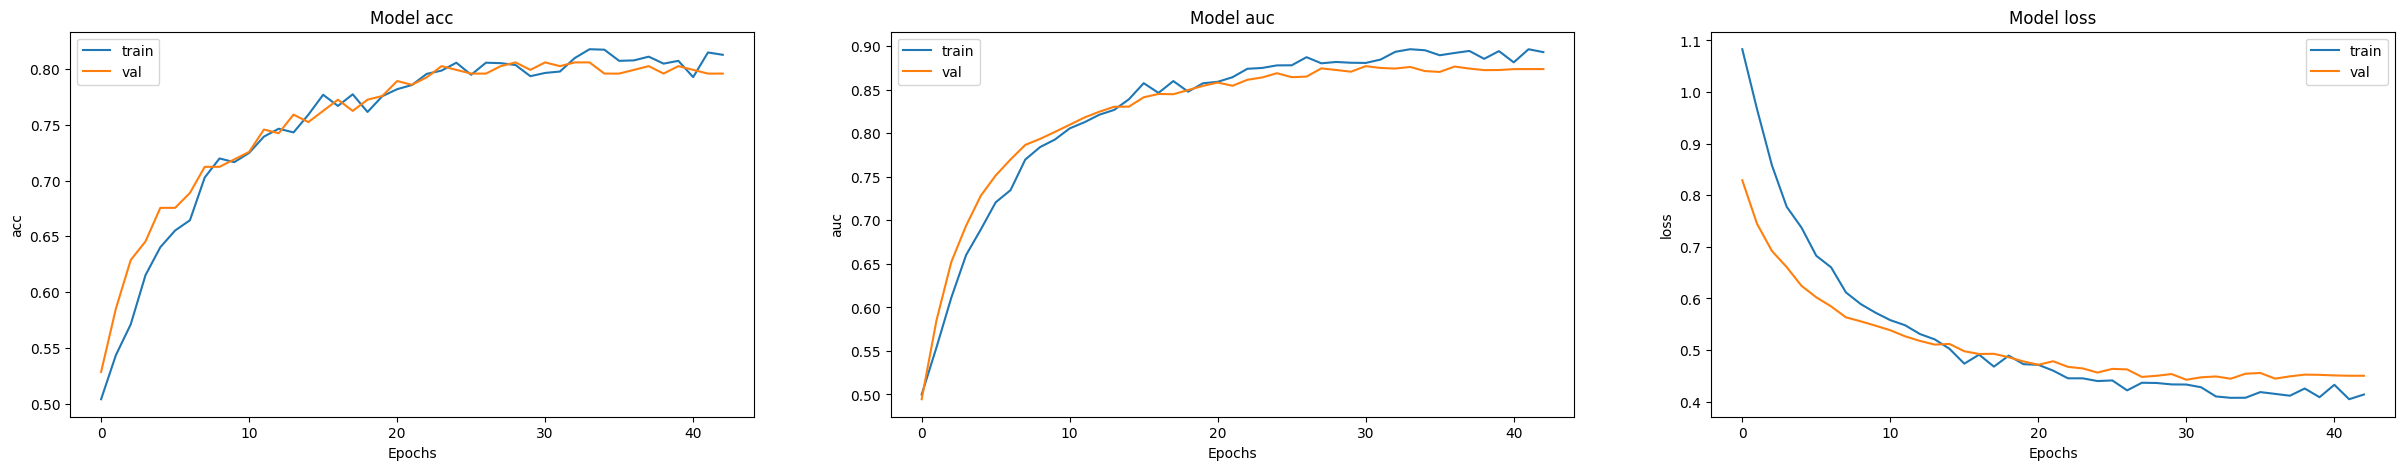

In [21]:
# ===============================
# 13 Plot Training Metrics
# ===============================

fig, ax = plt.subplots(1, 3, figsize = (30, 5))
ax = ax.ravel()

for i, metric in enumerate(["acc", "auc", "loss"]):
    ax[i].plot(history.history[metric])
    ax[i].plot(history.history["val_" + metric])
    ax[i].set_title("Model {}".format(metric))
    ax[i].set_xlabel("Epochs")
    ax[i].set_ylabel(metric)
    ax[i].legend(["train", "val"])

plt.show()


In [22]:
# ===============================
# 14 Evaluate on Test Set
# ===============================

test_scores = model.evaluate(test_dataset)

print('Testing Accuracy: %.2f%%' % (test_scores[1] * 100))


10/10 [==============================] - 2s 127ms/step - loss: 0.3894 - acc: 0.8140 - auc: 0.9083
Testing Accuracy: 81.40%


In [23]:
# ===============================
# 15 Predictions
# ===============================

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())


1/1 [==============================] - 1s 1s/step


In [24]:
# ===============================
# 16 Classification Report
# ===============================

print(classification_report(y_true, y_pred, target_names=CLASSES))


              precision    recall  f1-score   support

        down       0.80      0.84      0.82       150
      normal       0.83      0.79      0.81       151

    accuracy                           0.81       301
   macro avg       0.81      0.81      0.81       301
weighted avg       0.81      0.81      0.81       301



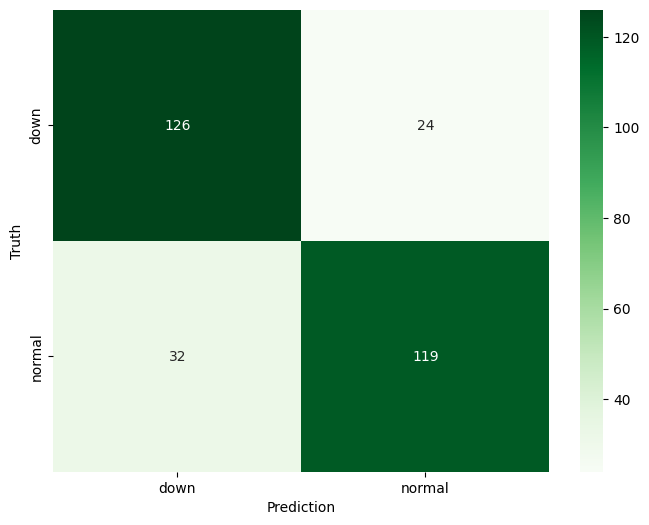

In [25]:
# ===============================
# 17 Confusion Matrix
# ===============================

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Greens",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    fmt="d"
)

plt.xlabel("Prediction")
plt.ylabel("Truth")

plt.show()


In [61]:
# ===============================
# 18 Save Model
# ===============================

model.save("alzheimer_resnet_model2.keras")
print("Model saved.")


Model saved.
